In [1]:
import pickle

data = pickle.load(open('../data/model_data_history/test/test.pkl', 'rb'))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.001s...
[t-SNE] Computed neighbors for 50000 samples in 0.526s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

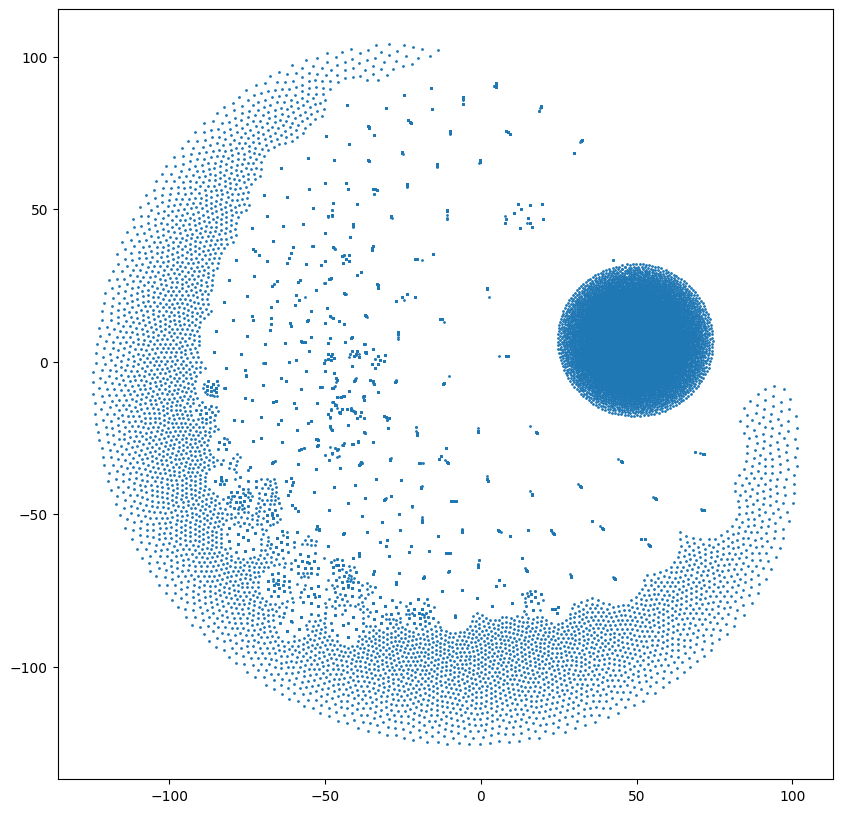

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

all_X = []
all_batch_ids = []

for i, batch in enumerate(data):
    x = batch.detach().cpu()
    all_X.append(x)
    all_batch_ids.append(
        torch.full((x.size(0),), i)
    )

X = torch.cat(all_X, dim=0).numpy()
batch_ids = torch.cat(all_batch_ids).numpy()

X = X[:50000]

S = cosine_similarity(X)
mask = ~np.eye(S.shape[0], dtype=bool)
mean_similarity = S[mask].mean()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='random',
    max_iter=1000,
    verbose=1
)

X_2d = tsne.fit_transform(X)

plt.figure(figsize=(10, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=1)
plt.show()

In [9]:
import pickle 

loader = pickle.load(open('../data/model_data_history/test/loader.pkl', 'rb'))
loader

/home/oai-5g-cn/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NeighborLoader()

In [36]:
all_Y = []
all_batch_ids = []

for i, batch in enumerate(loader):
    y = batch.type
    all_Y.append(y)

Y = torch.cat(all_Y, dim=0).numpy()
Y = Y[:50000]

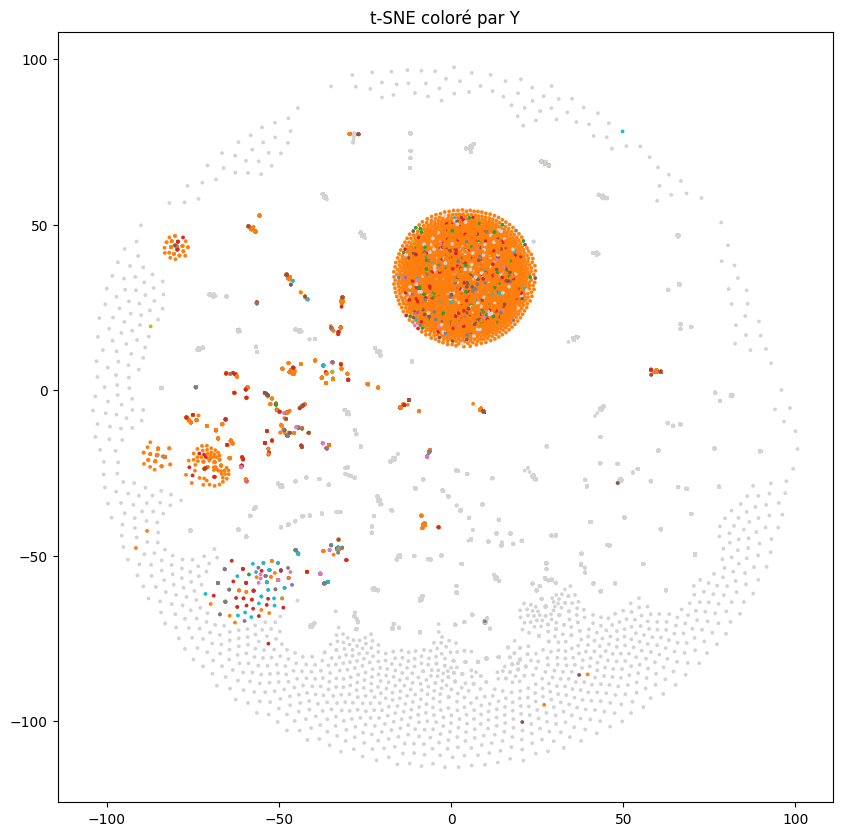

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

unique_labels = np.unique(Y)

# --- palette (-1 à 10) ---
palette = {lbl: ("lightgray" if lbl == -1 else plt.cm.tab10((lbl + 1) % len(unique_labels))) for lbl in unique_labels}

# --- couleurs des points ---
point_colors = [palette[lbl] for lbl in Y]

# --- plot ---
plt.figure(figsize=(10, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=3)
plt.title("t-SNE coloré par Y")

plt.show()


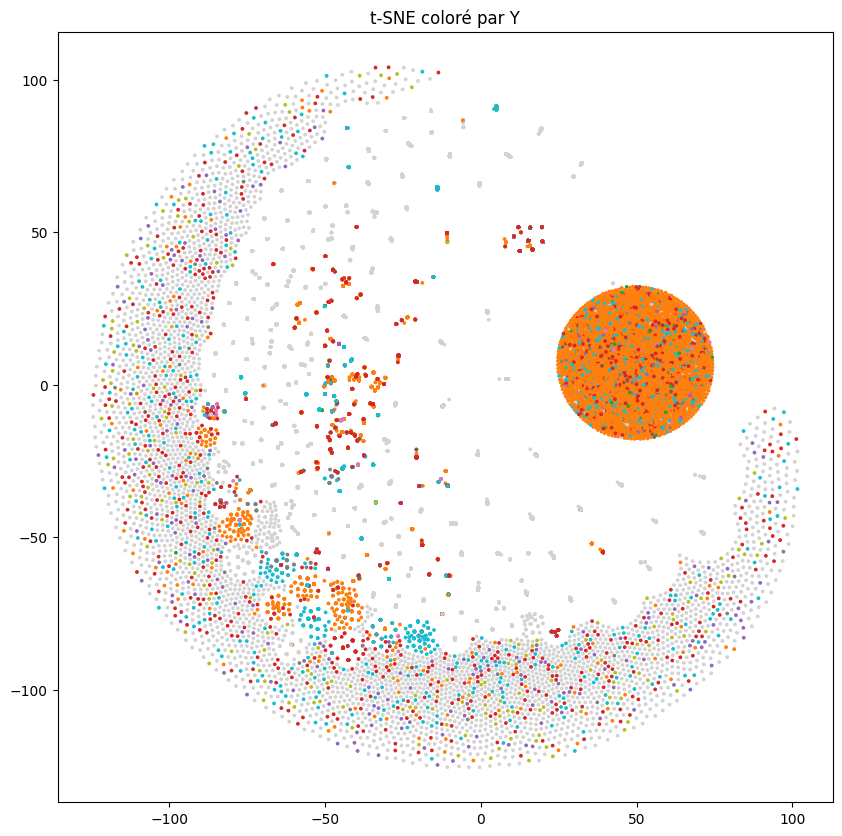

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

unique_labels = np.unique(Y)

# --- palette (-1 à 10) ---
palette = {lbl: ("lightgray" if lbl == -1 else plt.cm.tab10((lbl + 1) % len(unique_labels))) for lbl in unique_labels}

# --- couleurs des points ---
point_colors = [palette[lbl] for lbl in Y]

# --- plot ---
plt.figure(figsize=(10, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=3)
plt.title("t-SNE coloré par Y")

plt.show()
